# Tugas Analisis Numerik: Perhitungan Volume Lambung Kapal Katamaran

Nama : Talitha Zuhratul Amaliyyah
NPM : 25083010020
Mata Kuliah : Analisis Numerik A083
### Catatan & Asumsi Pengerjaan
* **Skala Grid**: Sesuai konfirmasi dosen pengampu, **1 dash-kosong = 45 cm (0.45 m)**.
* **Bentuk Penampang**: Lantai kapal dianggap datar (tanpa *keel*) sehingga penampang lintang berbentuk persegi panjang: $A(x) = W(x) \times H(x)$.
* **Batas Perhitungan**: Volume *reserve buoyancy* tidak dihitung sesuai instruksi tugas.
* **Metode**: Menggunakan integrasi numerik Aturan Trapesium (*Trapezoidal Rule*).
* **Target Output**: Volume total untuk kedua lambung kapal katamaran ($V_{\text{total}} = 2 \times V_{\text{1 lambung}}$).

In [11]:
import numpy as np

# Konfigurasi parameter skala grid
DASH_KOSONG_CM = 45.0  # Ukuran 1 dash-kosong dalam cm
DELTA_X = DASH_KOSONG_CM / 100.0  # Konversi ke meter (0.45 m)

print(f"--- PARAMETER SKALA ---")
print(f"1 dash-kosong = {DASH_KOSONG_CM} cm -> Delta X = {DELTA_X} meter")

--- PARAMETER SKALA ---
1 dash-kosong = 45.0 cm -> Delta X = 0.45 meter


Cell ini mendefinisikan library NumPy dan variabel parameter utama ($\Delta x$). Mengisolasinya dalam cell tersendiri memudahkan jika ingin mengganti nilai skala grid di kemudian hari tanpa mengganggu kode lainnya.

In [12]:
# Input data ukuran dari pembacaan grid gambar
# Nilai dimasukkan dalam satuan JUMLAH GRID

grid_lebar = np.array([0.0, 0.8, 1.2, 1.5, 1.5, 1.5, 1.5, 1.2, 0.8, 0.0])
grid_tinggi = np.array([0.0, 0.5, 0.8, 1.0, 1.0, 1.0, 1.0, 0.8, 0.5, 0.0])

# Konversi ukuran grid ke satuan meter (m)
lebar_m = grid_lebar * DELTA_X
tinggi_m = grid_tinggi * DELTA_X

# Hitung luas penampang A(x) = Lebar * Tinggi (m^2)
luas_penampang = lebar_m * tinggi_m

print("Data luas penampang di setiap stasiun grid (m²):")
print(luas_penampang)

Data luas penampang di setiap stasiun grid (m²):
[0.      0.081   0.1944  0.30375 0.30375 0.30375 0.30375 0.1944  0.081
 0.     ]


Cell ini memuat array data hasil pembacaan grid (lebar dan tinggi). Nilai grid dikalikan dengan $\Delta x$ ($0,45\text{ m}$) untuk mendapatkan ukuran sebenarnya dalam meter, lalu dihitung luas penampangnya di tiap titik.

In [13]:
# Hitung volume 1 lambung menggunakan Metode Trapesium (np.trapezoid untuk NumPy terbaru)
try:
    volume_satu_lambung = np.trapezoid(luas_penampang, dx=DELTA_X)
except AttributeError:
    volume_satu_lambung = np.trapz(luas_penampang, dx=DELTA_X)

# Hitung total volume kedua lambung (Katamaran = 2 lambung simetris)
volume_total = 2 * volume_satu_lambung

# Tampilkan hasil akhir
print("=" * 50)
print("HASIL PERHITUNGAN VOLUME")
print("=" * 50)
print(f"Jumlah Titik Grid (n+1) : {len(grid_lebar)}")
print(f"Volume 1 Lambung         : {volume_satu_lambung:.4f} m³ ({volume_satu_lambung * 1000:.2f} Liter)")
print(f"Total Volume 2 Lambung   : {volume_total:.4f} m³ ({volume_total * 1000:.2f} Liter)")
print("=" * 50)

HASIL PERHITUNGAN VOLUME
Jumlah Titik Grid (n+1) : 10
Volume 1 Lambung         : 0.7946 m³ (794.61 Liter)
Total Volume 2 Lambung   : 1.5892 m³ (1589.22 Liter)


Cell ini melakukan proses integrasi numerik menggunakan aturan Trapesium untuk menghitung luas di bawah kurva penampang sepanjang sumbu $x$, kemudian mengalikannya dengan 2 untuk mendapatkan total volume kapal katamaran.

In [14]:
# Hitung volume 1 lambung menggunakan Metode Trapesium
volume_satu_lambung = np.trapz(luas_penampang, dx=DELTA_X)

# Hitung total volume kedua lambung (Katamaran = 2 lambung simetris)
volume_total = 2 * volume_satu_lambung

# Tampilkan hasil akhir
print("=" * 50)
print("HASIL PERHITUNGAN VOLUME")
print("=" * 50)
print(f"Jumlah Titik Grid (n+1) : {len(grid_lebar)}")
print(f"Volume 1 Lambung         : {volume_satu_lambung:.4f} m³ ({volume_satu_lambung * 1000:.2f} Liter)")
print(f"Total Volume 2 Lambung   : {volume_total:.4f} m³ ({volume_total * 1000:.2f} Liter)")
print("=" * 50)

HASIL PERHITUNGAN VOLUME
Jumlah Titik Grid (n+1) : 10
Volume 1 Lambung         : 0.7946 m³ (794.61 Liter)
Total Volume 2 Lambung   : 1.5892 m³ (1589.22 Liter)


/tmp/ipykernel_2013/4026032122.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  volume_satu_lambung = np.trapz(luas_penampang, dx=DELTA_X)


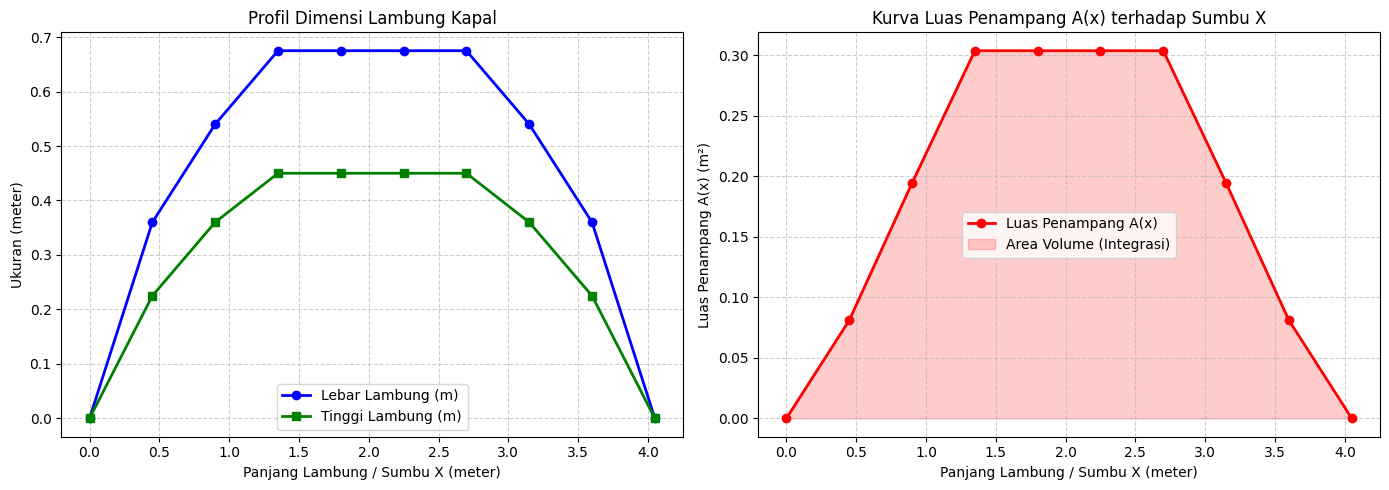

In [15]:
# Import library untuk visualisasi
import matplotlib.pyplot as plt

# Membuat grid visualisasi (1 baris, 2 kolom)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sumbu X dalam satuan meter
x_m = np.arange(len(grid_lebar)) * DELTA_X

# --- GRAFIK 1: Profil Lebar & Tinggi Lambung ---
ax1.plot(x_m, lebar_m, 'b-o', label='Lebar Lambung (m)', linewidth=2)
ax1.plot(x_m, tinggi_m, 'g-s', label='Tinggi Lambung (m)', linewidth=2)
ax1.set_title('Profil Dimensi Lambung Kapal')
ax1.set_xlabel('Panjang Lambung / Sumbu X (meter)')
ax1.set_ylabel('Ukuran (meter)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# --- GRAFIK 2: Kurva Luas Penampang A(x) & Area Integrasi Trapesium ---
ax2.plot(x_m, luas_penampang, 'r-o', label='Luas Penampang A(x)', linewidth=2)
ax2.fill_between(x_m, luas_penampang, color='red', alpha=0.2, label='Area Volume (Integrasi)')
ax2.set_title('Kurva Luas Penampang A(x) terhadap Sumbu X')
ax2.set_xlabel('Panjang Lambung / Sumbu X (meter)')
ax2.set_ylabel('Luas Penampang A(x) (m²)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

Grafik 1 (Kiri): Menampilkan bentuk perubahan lebar dan tinggi lambung kapal sepanjang sumbu $x$ (panjang lambung).
Grafik 2 (Kanan): Menampilkan plot luas penampang $A(x)$. Area terarsir di bawah kurva menunjukkan area yang dihitung nilainya menggunakan metode integrasi trapesium untuk menghasilkan volume lambung.